<a href="https://colab.research.google.com/github/MousiosV/Machine-Learning-Assignment/blob/main/Machine_Learning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Διαβάζουμε το αρχείο και το αποθηκεύουμε σε μια μεταβλητή με το όνομα 'df' (dataframe)
# Σημείωση: Αν το αρχείο σου έχει διαφορετικό όνομα, άλλαξέ το εδώ
df = pd.read_csv('sales_data_sample.csv', encoding='latin1')

# Εμφανίζουμε τις πρώτες 5 γραμμές του αρχείου για να δούμε ότι φορτώθηκε σωστά
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Φόρτωση δεδομένων (βάζουμε encoding='latin1' για να μην βγάλει error με ειδικούς χαρακτήρες)
df = pd.read_csv('sales_data_sample.csv', encoding='latin1')
df.columns = df.columns.str.upper() # Τα κάνουμε όλα κεφαλαία για ευκολία

In [ ]:
# Βρίσκουμε και τυπώνουμε μόνο τις στήλες που έχουν έστω και 1 κενή τιμή
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64


In [ ]:
# Εμφάνιση πληροφοριών για όλες τις στήλες του dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


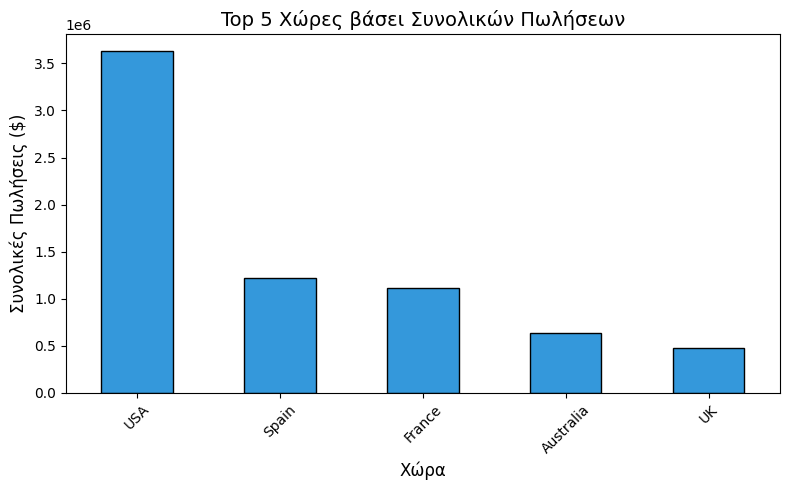

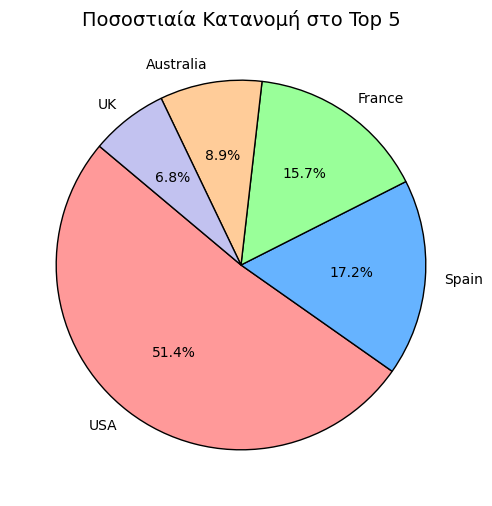

In [ ]:
# Υπολογισμός των top 5 χωρών βάσει του αθροίσματος των πωλήσεων
top5_countries = df.groupby('COUNTRY')['SALES'].sum().nlargest(5)

# 1. Δημιουργία Bar Plot
plt.figure(figsize=(8, 5))
top5_countries.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Top 5 Χώρες βάσει Συνολικών Πωλήσεων', fontsize=14)
plt.ylabel('Συνολικές Πωλήσεις ($)', fontsize=12)
plt.xlabel('Χώρα', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n") # Κενό για να ξεχωρίζουν τα γραφήματα

# 2. Δημιουργία Pie Chart
plt.figure(figsize=(6, 6))
top5_countries.plot(kind='pie', autopct='%1.1f%%', startangle=140,
                    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
                    wedgeprops={'edgecolor': 'black'})
plt.title('Ποσοστιαία Κατανομή στο Top 5', fontsize=14)
plt.ylabel('')
plt.show()

In [ ]:
# Ορίζουμε τις στήλες που θέλουμε να αναλύσουμε
variables = ['QUANTITYORDERED', 'SALES']

# Φτιάχνουμε μια λούπα για να τυπώσει τα στατιστικά όμορφα και για τις δύο
for var in variables:
    print(f"--- Στατιστική Ανάλυση για: {var} ---")
    print(f"Μέσος Όρος (Mean):       {df[var].mean():.2f}")
    print(f"Διάμεσος (Median):       {df[var].median():.2f}")
    print(f"Επικρατούσα Τιμή (Mode): {df[var].mode()[0]:.2f}")
    print(f"Ελάχιστη Τιμή (Min):     {df[var].min():.2f}")
    print(f"Μέγιστη Τιμή (Max):      {df[var].max():.2f}")
    print("\n")

--- Στατιστική Ανάλυση για: QUANTITYORDERED ---
Μέσος Όρος (Mean):       35.09
Διάμεσος (Median):       35.00
Επικρατούσα Τιμή (Mode): 34.00
Ελάχιστη Τιμή (Min):     6.00
Μέγιστη Τιμή (Max):      97.00


--- Στατιστική Ανάλυση για: SALES ---
Μέσος Όρος (Mean):       3553.89
Διάμεσος (Median):       3184.80
Επικρατούσα Τιμή (Mode): 3003.00
Ελάχιστη Τιμή (Min):     482.13
Μέγιστη Τιμή (Max):      14082.80




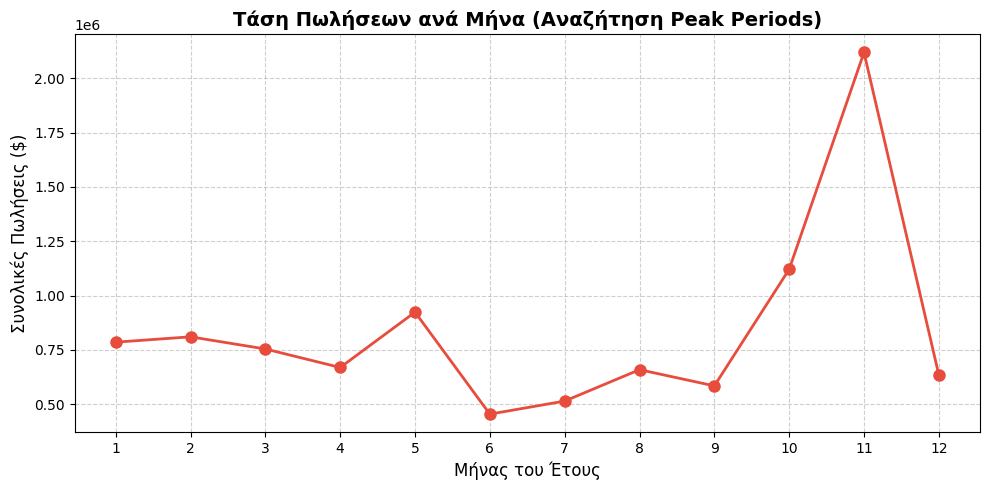

In [ ]:
# Ομαδοποίηση των πωλήσεων ανά μήνα (MONTH_ID)
monthly_sales = df.groupby('MONTH_ID')['SALES'].sum()

# Δημιουργία γραφήματος για την τάση (Trend)
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o', color='#e74c3c', linewidth=2, markersize=8)

# Μορφοποίηση του γραφήματος
plt.title('Τάση Πωλήσεων ανά Μήνα (Αναζήτηση Peak Periods)', fontsize=14, fontweight='bold')
plt.xlabel('Μήνας του Έτους', fontsize=12)
plt.ylabel('Συνολικές Πωλήσεις ($)', fontsize=12)
plt.xticks(range(1, 13)) # Για να δείχνει όλους τους μήνες από το 1 έως το 12
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

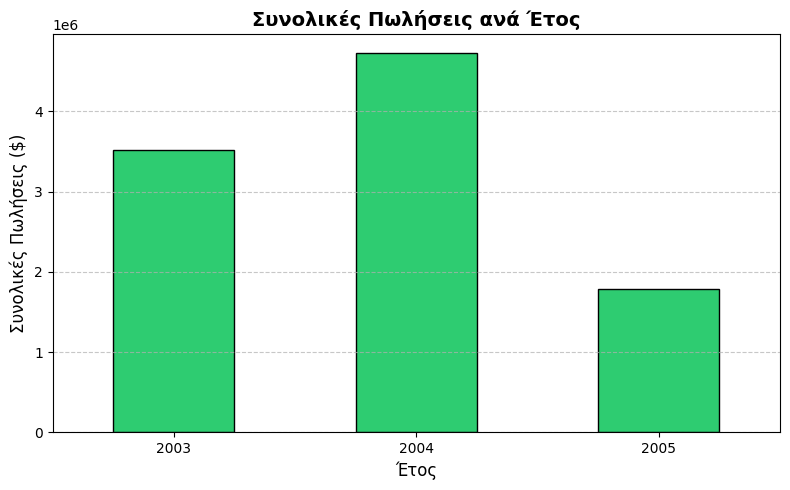


--- Έλεγχος Δεδομένων για το 2005 ---
Διαθέσιμοι μήνες καταγραφής για το 2005: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
# Υπολογισμός συνολικών πωλήσεων ανά έτος
yearly_sales = df.groupby('YEAR_ID')['SALES'].sum()

# Δημιουργία Bar Plot
plt.figure(figsize=(8, 5))
yearly_sales.plot(kind='bar', color='#2ecc71', edgecolor='black')
plt.title('Συνολικές Πωλήσεις ανά Έτος', fontsize=14, fontweight='bold')
plt.xlabel('Έτος', fontsize=12)
plt.ylabel('Συνολικές Πωλήσεις ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Έλεγχος Δεδομένων για το 2005 ---")
# Ελέγχουμε ποιους μήνες έχουμε διαθέσιμους για το 2005
months_2005 = df[df['YEAR_ID'] == 2005]['MONTH_ID'].unique()
print(f"Διαθέσιμοι μήνες καταγραφής για το 2005: {sorted(months_2005)}")

--- Πτώση Πωλήσεων ανά Κατηγορία (2004 vs 2005) ---
PRODUCTLINE
Classic Cars        1089683.81
Vintage Cars         570684.46
Trucks and Buses     351245.87
Motorcycles          325597.70
Planes               302597.63
Ships                213259.90
Trains                79606.52
Name: SALES, dtype: float64


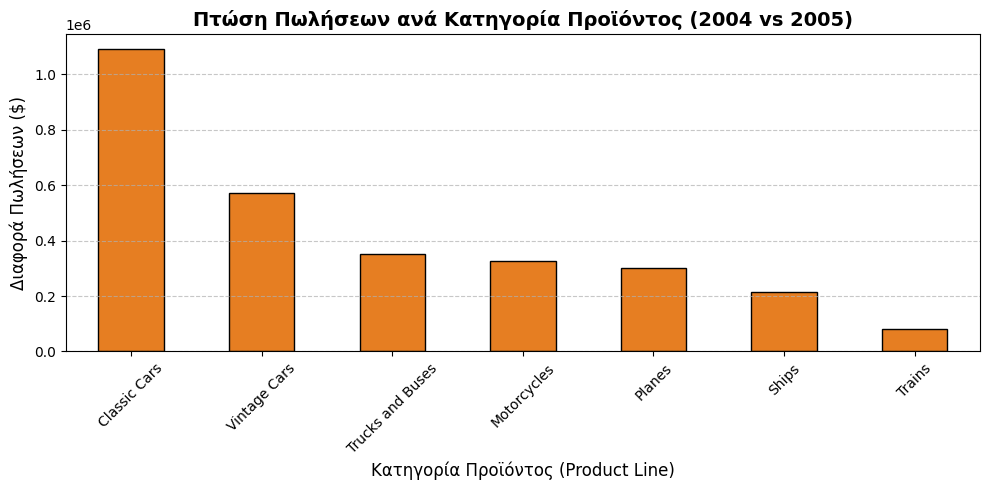

In [ ]:
# Υπολογισμός συνολικών πωλήσεων ανά κατηγορία προϊόντος για το 2004
sales_2004 = df[df['YEAR_ID'] == 2004].groupby('PRODUCTLINE')['SALES'].sum()

# Υπολογισμός συνολικών πωλήσεων ανά κατηγορία προϊόντος για το 2005
sales_2005 = df[df['YEAR_ID'] == 2005].groupby('PRODUCTLINE')['SALES'].sum()

# Υπολογισμός της πτώσης (Πωλήσεις 2004 - Πωλήσεις 2005)
# Το fillna(0) διασφαλίζει ότι αν ένα προϊόν δεν πούλησε καθόλου το 2005, δεν θα βγάλει error
sales_drop = sales_2004.subtract(sales_2005, fill_value=0)

# Ταξινομούμε για να βρούμε τη μεγαλύτερη πτώση
sales_drop = sales_drop.sort_values(ascending=False)

print("--- Πτώση Πωλήσεων ανά Κατηγορία (2004 vs 2005) ---")
print(sales_drop)

# Οπτικοποίηση της πτώσης
plt.figure(figsize=(10, 5))
sales_drop.plot(kind='bar', color='#e67e22', edgecolor='black')
plt.title('Πτώση Πωλήσεων ανά Κατηγορία Προϊόντος (2004 vs 2005)', fontsize=14, fontweight='bold')
plt.xlabel('Κατηγορία Προϊόντος (Product Line)', fontsize=12)
plt.ylabel('Διαφορά Πωλήσεων ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Συχνότητα Παραγγελιών ανά Κατηγορία ---
PRODUCTLINE
Classic Cars        967
Vintage Cars        607
Motorcycles         331
Planes              306
Trucks and Buses    301
Ships               234
Trains               77
Name: count, dtype: int64


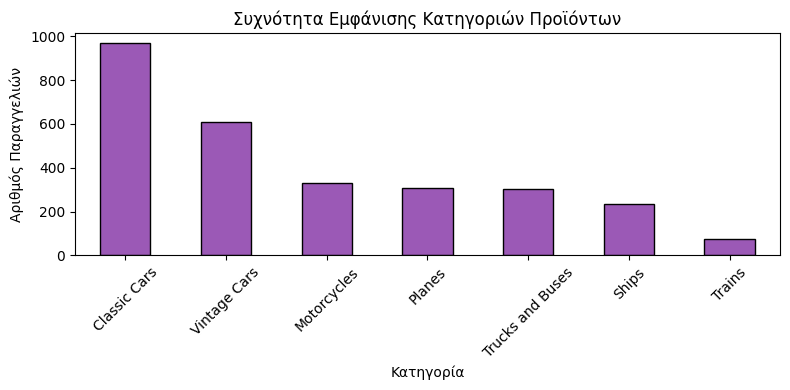

In [ ]:
# Καταμέτρηση της συχνότητας (πλήθος παραγγελιών) ανά κατηγορία
product_frequencies = df['PRODUCTLINE'].value_counts()
print("--- Συχνότητα Παραγγελιών ανά Κατηγορία ---")
print(product_frequencies)

# Οπτικοποίηση
plt.figure(figsize=(8, 4))
product_frequencies.plot(kind='bar', color='#9b59b6', edgecolor='black')
plt.title('Συχνότητα Εμφάνισης Κατηγοριών Προϊόντων', fontsize=12)
plt.xlabel('Κατηγορία', fontsize=10)
plt.ylabel('Αριθμός Παραγγελιών', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

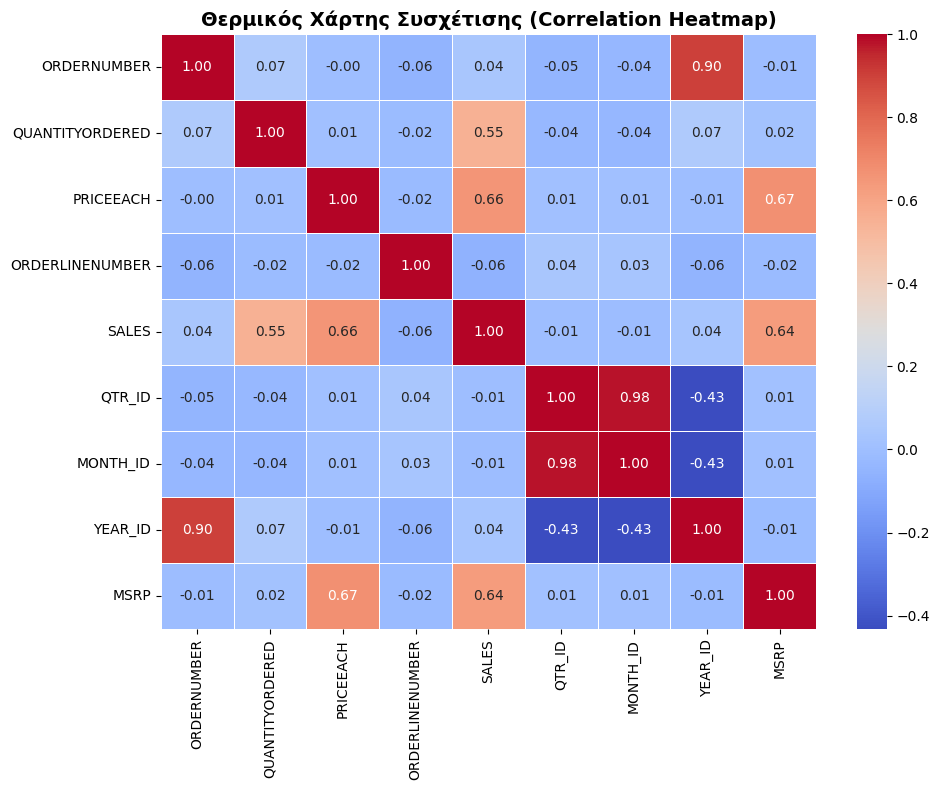

In [ ]:
# Επιλέγουμε ΜΟΝΟ τις αριθμητικές στήλες για να μην βγάλει error η correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Υπολογίζουμε τη συσχέτιση (Pearson correlation)
corr_matrix = numeric_cols.corr()

# Φτιάχνουμε το Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Θερμικός Χάρτης Συσχέτισης (Correlation Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

# 1. Φόρτωση των τριών αρχείων
features = pd.read_csv('Features data set.csv')
sales = pd.read_csv('sales data-set.csv')
stores = pd.read_csv('stores data-set.csv')

# 2. Ενοποίηση (Merge) των αρχείων
# Ενώνουμε πρώτα τα sales με τα features (με βάση το κατάστημα, την ημερομηνία και τις αργίες)
merged_df = pd.merge(sales, features, on=['Store', 'Date', 'IsHoliday'], how='inner')
# Μετά ενώνουμε το αποτέλεσμα με τα stores (με βάση το κατάστημα)
final_df = pd.merge(merged_df, stores, on=['Store'], how='inner')

# 3. Εμφάνιση των στηλών για να κάνουμε την επιλογή (Feature Selection)
print("--- Διαθέσιμες Μεταβλητές στο ενοποιημένο Dataset ---")
final_df.info()

--- Διαθέσιμες Μεταβλητές στο ενοποιημένο Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), obj

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Επιλογή ενός συγκεκριμένου καταστήματος (π.χ. Store 1)
store_data = final_df[final_df['Store'] == 1].copy()

# Μετατρέπουμε το IsHoliday σε 0 και 1 (από True/False) για να το καταλάβει το μοντέλο
store_data['IsHoliday'] = store_data['IsHoliday'].astype(int)

# 2. Ορισμός των ανεξάρτητων μεταβλητών (X) και της εξαρτημένης/στόχου (y)
features_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday']
X = store_data[features_cols]
y = store_data['Weekly_Sales']

# 3. Διαχωρισμός σε Train (80%) και Test (20%) set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Εκπαίδευση του Μοντέλου Πολλαπλής Γραμμικής Παλινδρόμησης
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Πραγματοποίηση προβλέψεων στο test set
y_pred = model.predict(X_test)

# 6. Αξιολόγηση με το Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

print("--- Αποτελέσματα Μοντέλου Πολλαπλής Γραμμικής Παλινδρόμησης (Store 1) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}") # Το βάζουμε για να βγάζει νόημα στα συμπεράσματα

--- Αποτελέσματα Μοντέλου Πολλαπλής Γραμμικής Παλινδρόμησης (Store 1) ---
Mean Squared Error (MSE): 721493459.20
Root Mean Squared Error (RMSE): 26860.63


<Figure size 1000x800 with 0 Axes>

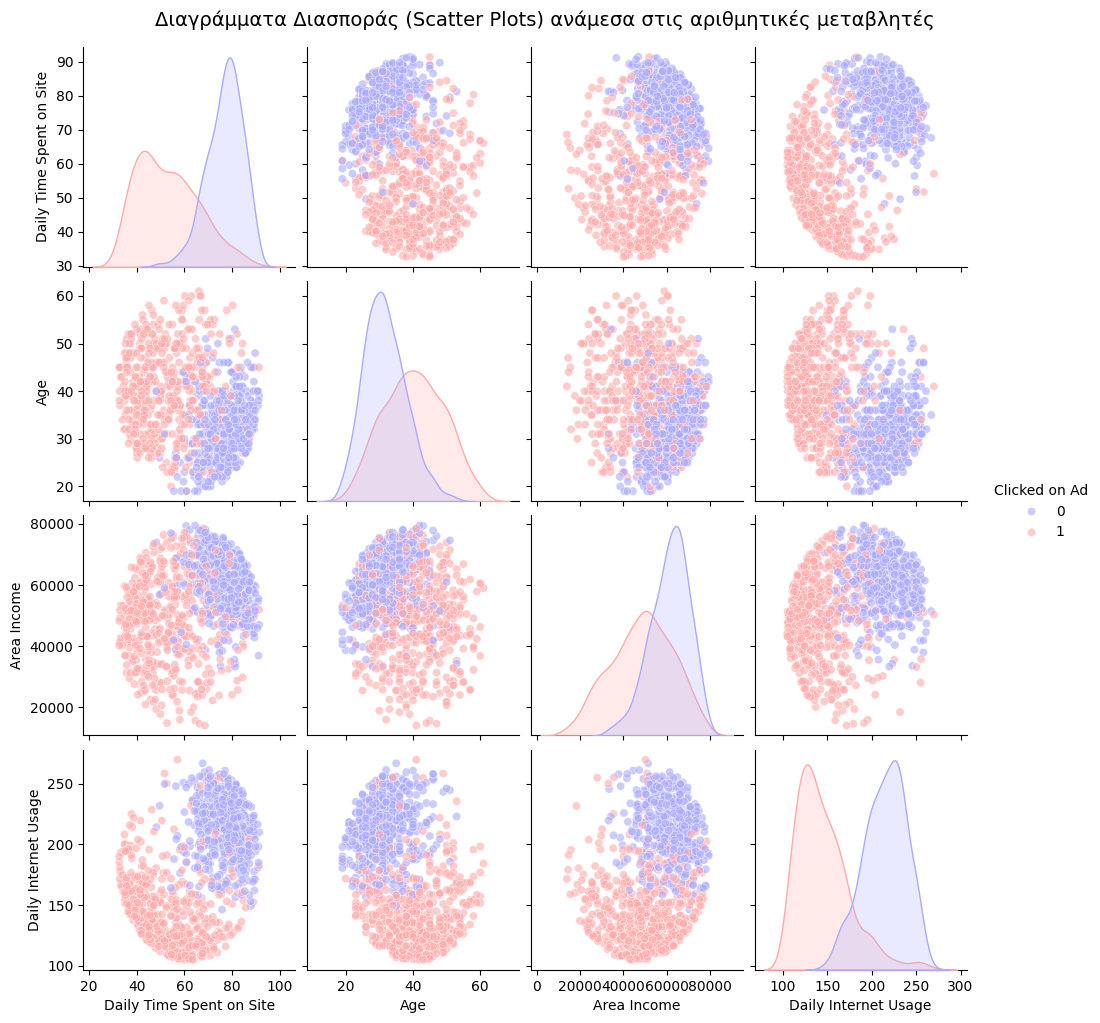

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Φόρτωση του νέου dataset
ad_df = pd.read_csv('advertising.csv')

# 2. Φιλτράρισμα μόνο των αριθμητικών στηλών (για να αποφύγουμε errors)
numeric_ad_cols = ad_df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']]

# 3. Δημιουργία Scatter Plots (Pairplot)
# Χρησιμοποιούμε το hue='Clicked on Ad' για να δούμε τα κλικ με διαφορετικό χρώμα!
plt.figure(figsize=(10, 8))
sns.pairplot(ad_df, vars=['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage'],
             hue='Clicked on Ad', palette='bwr', plot_kws={'alpha': 0.6})
plt.suptitle('Διαγράμματα Διασποράς (Scatter Plots) ανάμεσα στις αριθμητικές μεταβλητές', y=1.02, fontsize=14)
plt.show()

In [4]:
# 1. Ορίζουμε τις Ανεξάρτητες Μεταβλητές (Predictors - X)
# Κρατάμε μόνο τις αριθμητικές στήλες και το φύλο (Male), απορρίπτοντας κείμενα (όπως Ad Topic Line, City)
X = ad_df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]

# 2. Ορίζουμε τη Μεταβλητή-Στόχο (Target - y)
y = ad_df['Clicked on Ad']

print("--- Ανεξάρτητες Μεταβλητές (Predictors - X) ---")
print(X.columns.tolist())

print("\n--- Μεταβλητή Στόχος (Target - y) ---")
print(y.name)

--- Ανεξάρτητες Μεταβλητές (Predictors - X) ---
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']

--- Μεταβλητή Στόχος (Target - y) ---
Clicked on Ad


--- Αξιολόγηση Μοντέλου Naïve Bayes ---
Confusion Matrix:
[[140   6]
 [  6 148]]

Συνολική Ακρίβεια (Accuracy): 96.00%


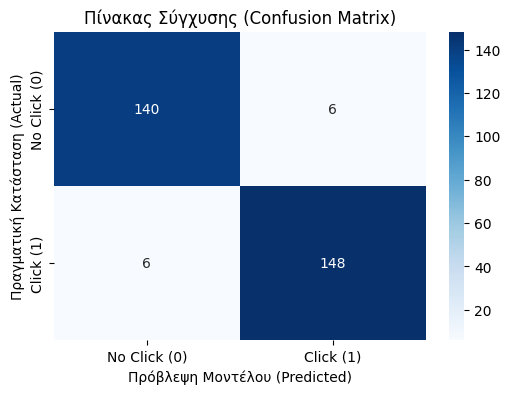

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Διαχωρισμός σε Train (70%) και Test (30%)
# Το random_state=42 εξασφαλίζει ότι θα έχουμε τα ίδια αποτελέσματα κάθε φορά που το τρέχουμε
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Αρχικοποίηση και εκπαίδευση του αλγορίθμου Gaussian Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 3. Προβλέψεις στο test set
y_pred = nb_model.predict(X_test)

# 4. Δημιουργία και εμφάνιση του Confusion Matrix και του Accuracy
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("--- Αξιολόγηση Μοντέλου Naïve Bayes ---")
print("Confusion Matrix:")
print(conf_matrix)
print(f"\nΣυνολική Ακρίβεια (Accuracy): {accuracy * 100:.2f}%")

# Προαιρετικά: Οπτικοποίηση του Confusion Matrix για να φαίνεται ωραίο στο Word
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Click (0)', 'Click (1)'],
            yticklabels=['No Click (0)', 'Click (1)'])
plt.title('Πίνακας Σύγχυσης (Confusion Matrix)')
plt.ylabel('Πραγματική Κατάσταση (Actual)')
plt.xlabel('Πρόβλεψη Μοντέλου (Predicted)')
plt.show()